In [2]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.io import fits

import healpy as hp

import minimint

from galpy.orbit import Orbit

from helpers import convert_galactic_to_mollweide

from survey import load_hvs_simulation_data, get_hvs_at_time, plot_initial_conditions, get_iso_data, load_footprint_mollweide_grid, \
    get_euclid_dr1_survey_cuts, get_hvs_survey_cuts, plot_galactic_distribution, plot_galactic_velocity

plt.rcParams['figure.dpi'] = 250
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams["text.usetex"] = True

%load_ext autoreload
%autoreload 2

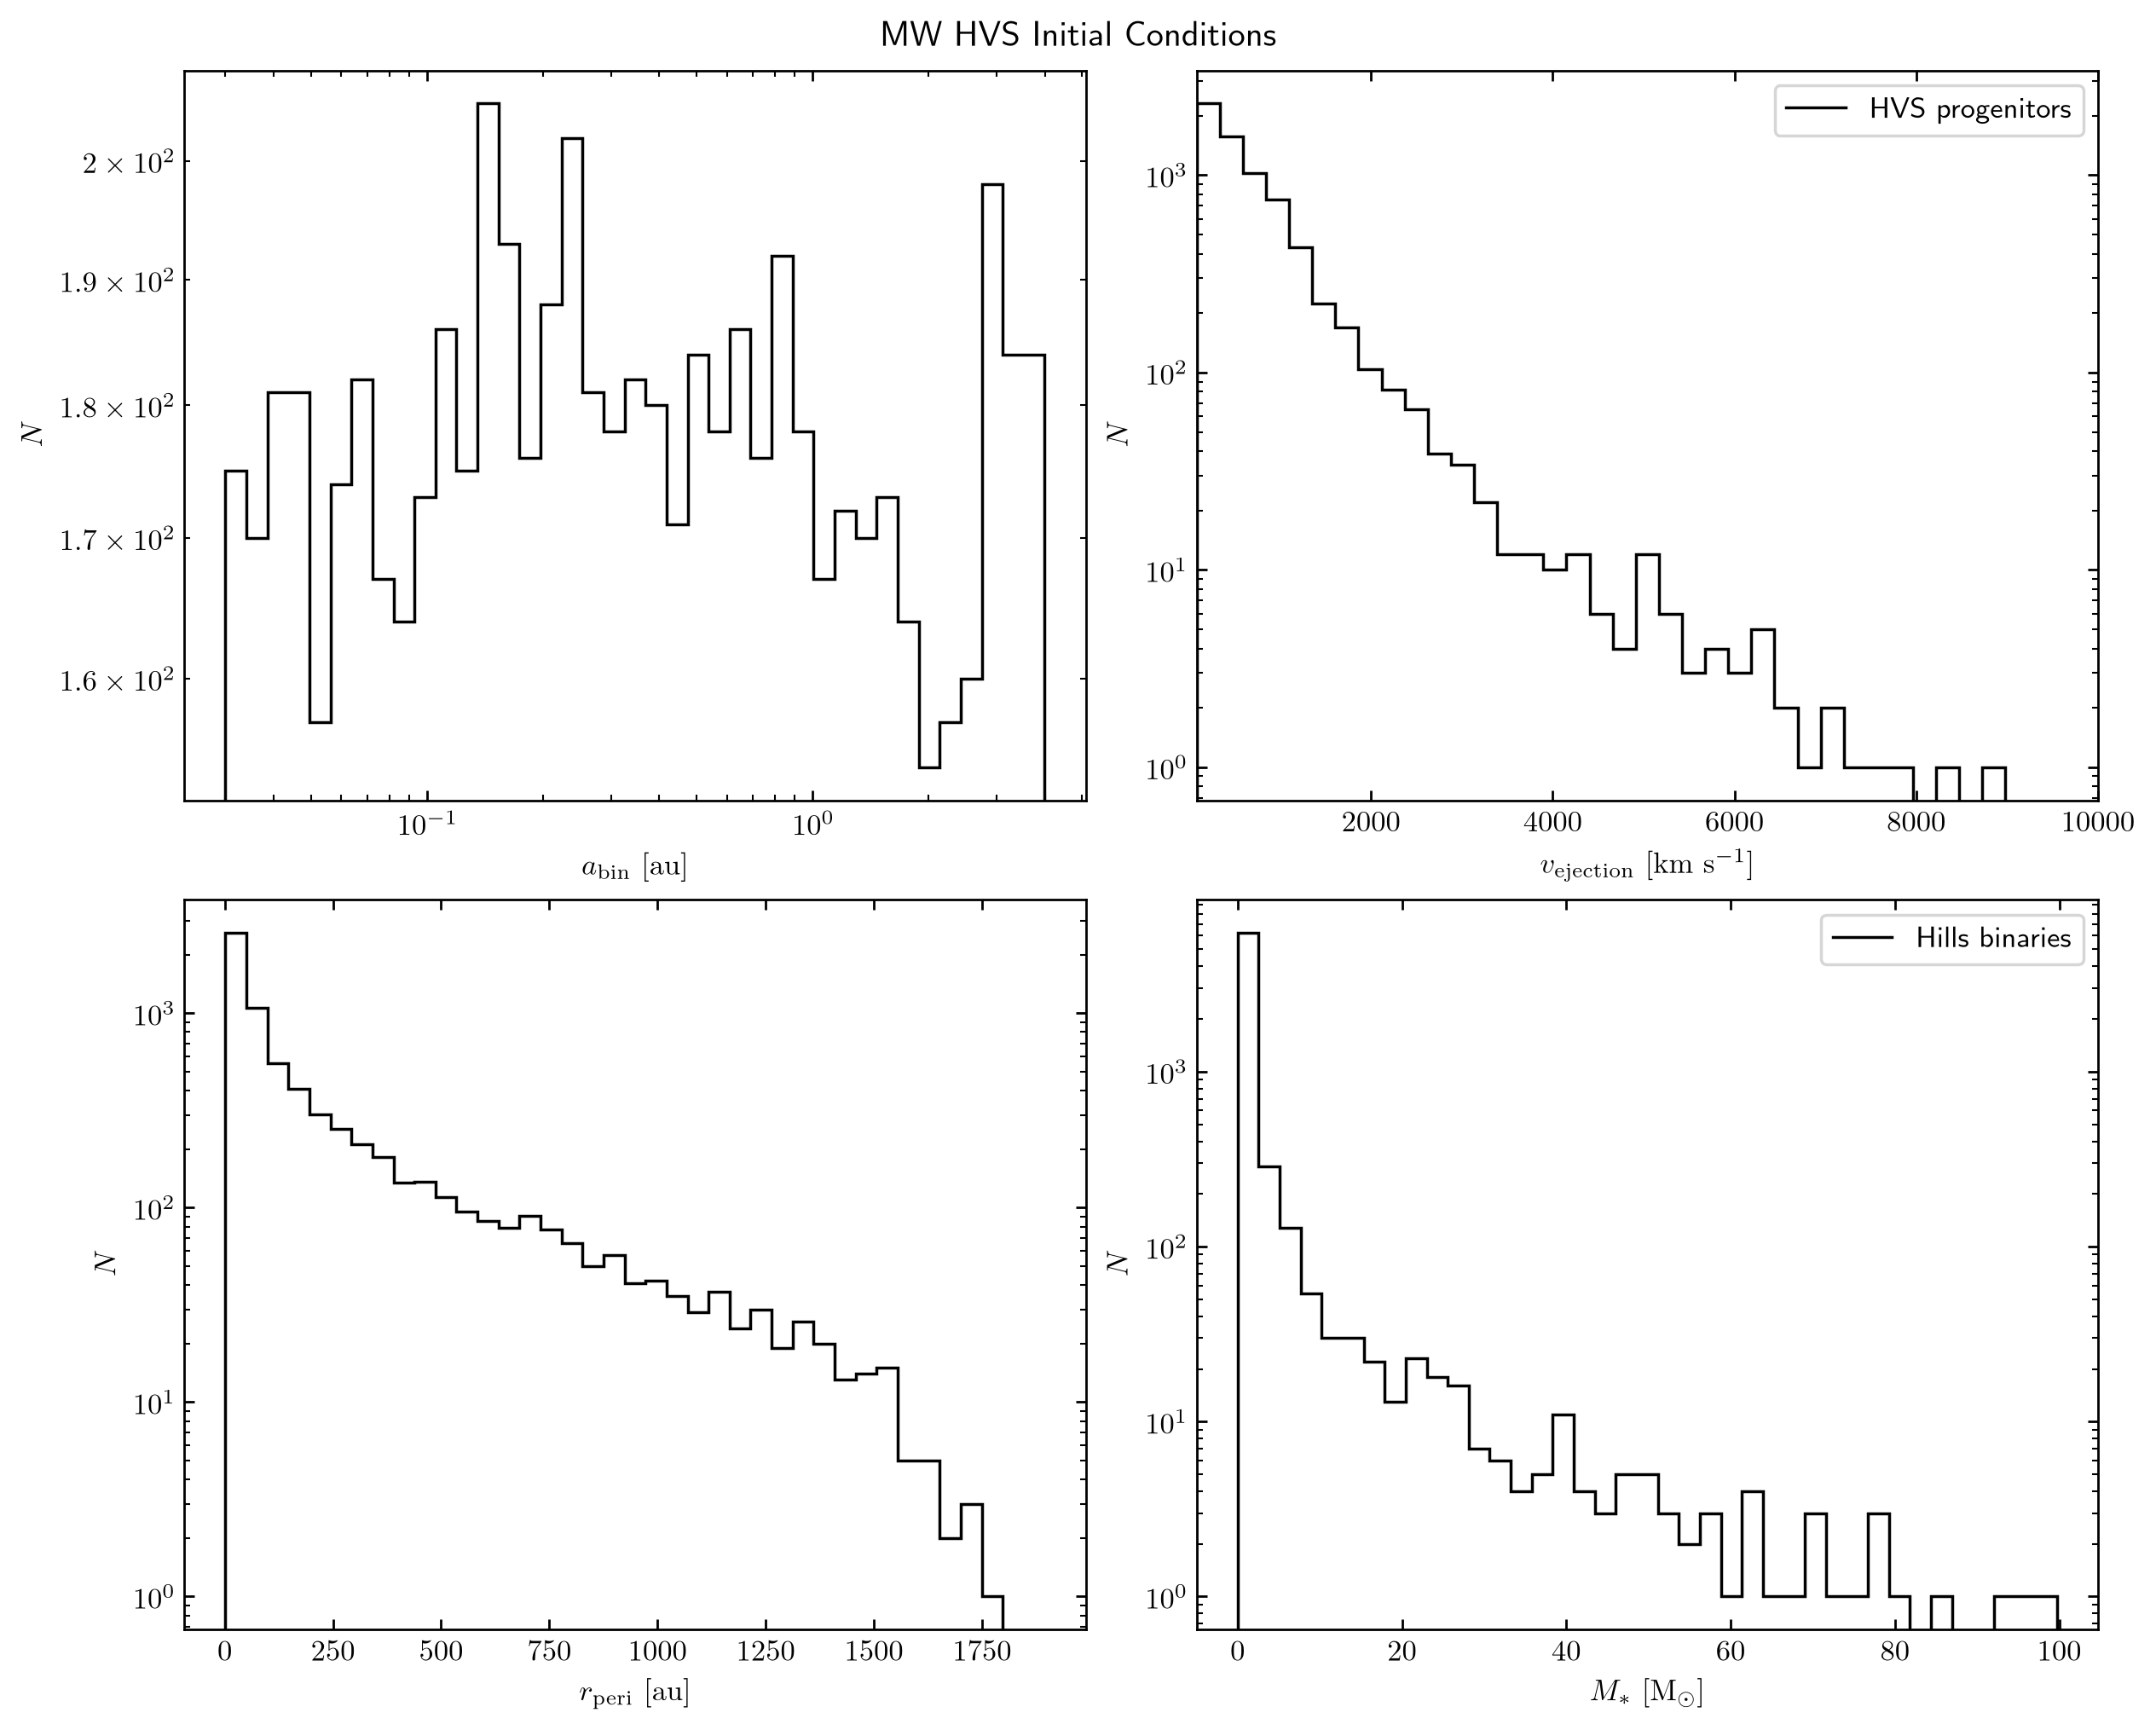

In [22]:
events, hvs_events, orbits = load_hvs_simulation_data("simulations/mw_test/r_peri_max/")
plot_initial_conditions(events, title="MW HVS Initial Conditions")

In [12]:
M_bh = 4e6 * u.Msun
a_bin = hvs_events['a_bin']
m_star_prim, m_star_sec = hvs_events['m_star_prim'], hvs_events['m_star_sec']
r_peri_max = a_bin * (3 * M_bh / (m_star_prim + m_star_sec))**(1/3) # tidal disruption radius for the binary
r_peri_max, hvs_events['r_peri']

(<Quantity [109.42110261,  12.51589885,  20.83444881, ...,  47.53062764,
            813.31196432,  53.47789695] AU>,
 <Quantity [109.42110261,  12.51589885,  20.83444881, ...,  47.53062764,
            813.31196432,  53.47789695] AU>)

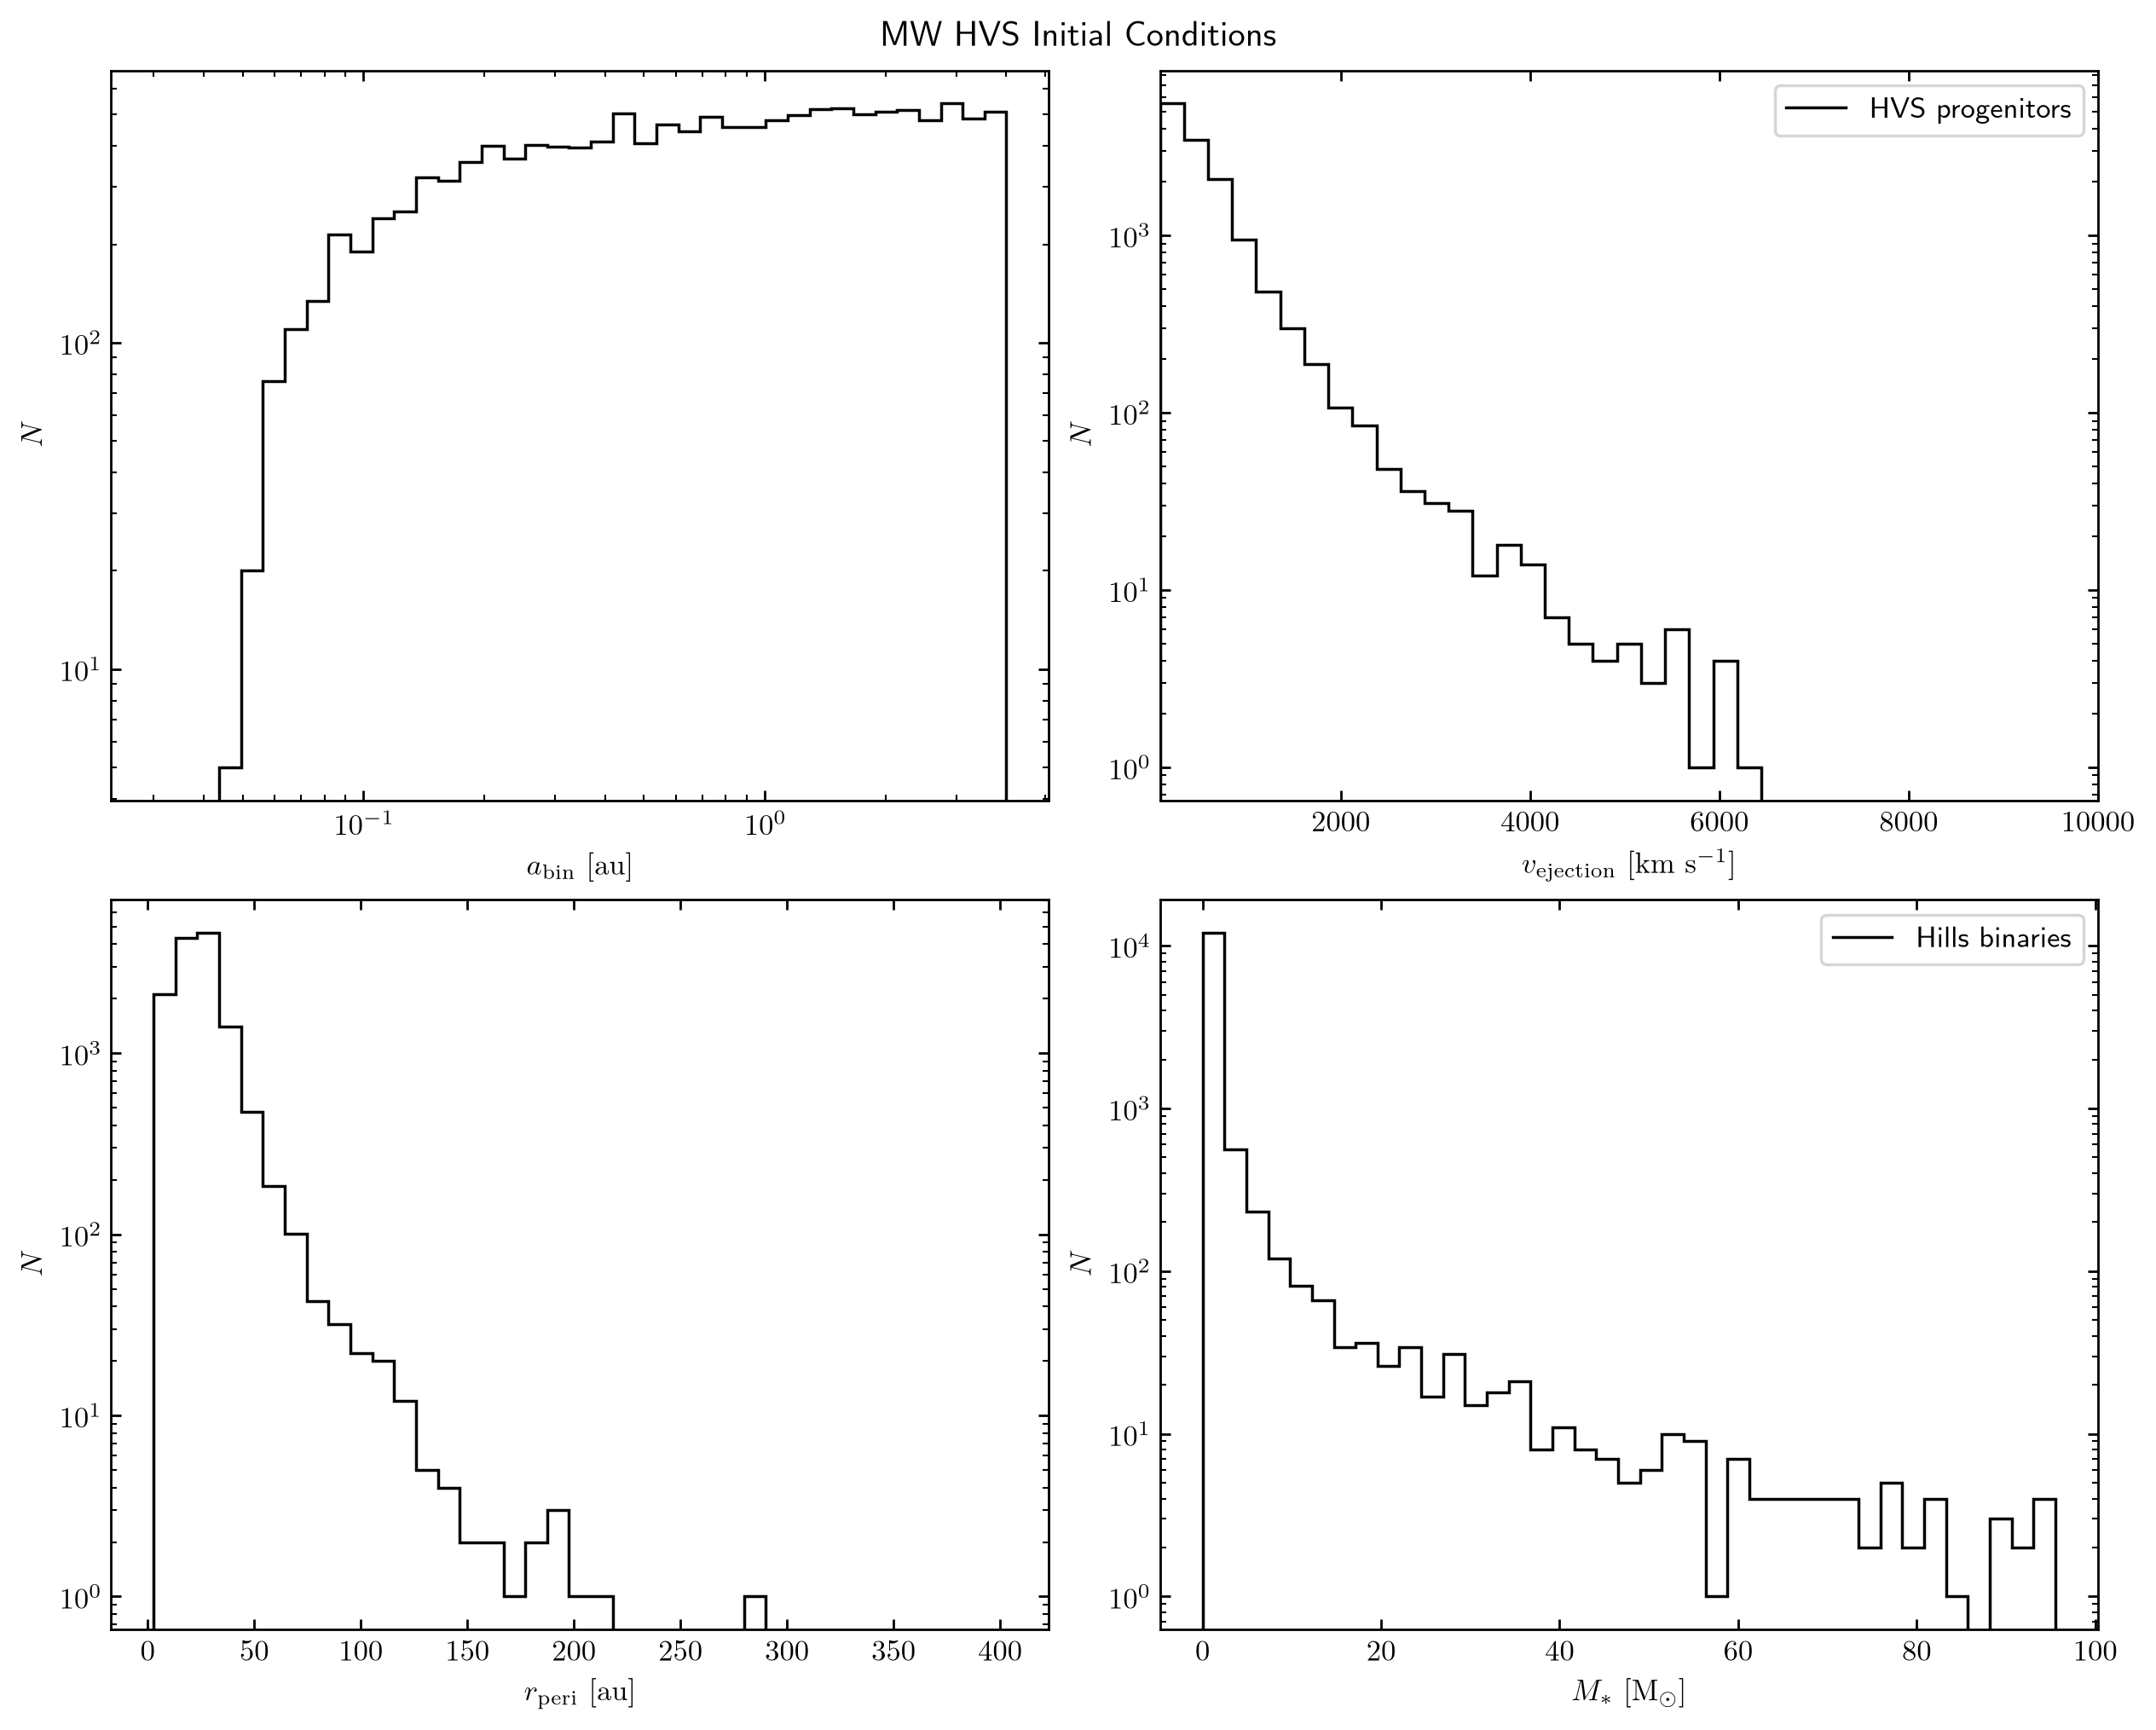

In [23]:
events, hvs_events, orbits = load_hvs_simulation_data("simulations/mw_test/r_peri_min/")
plot_initial_conditions(events, title="MW HVS Initial Conditions")

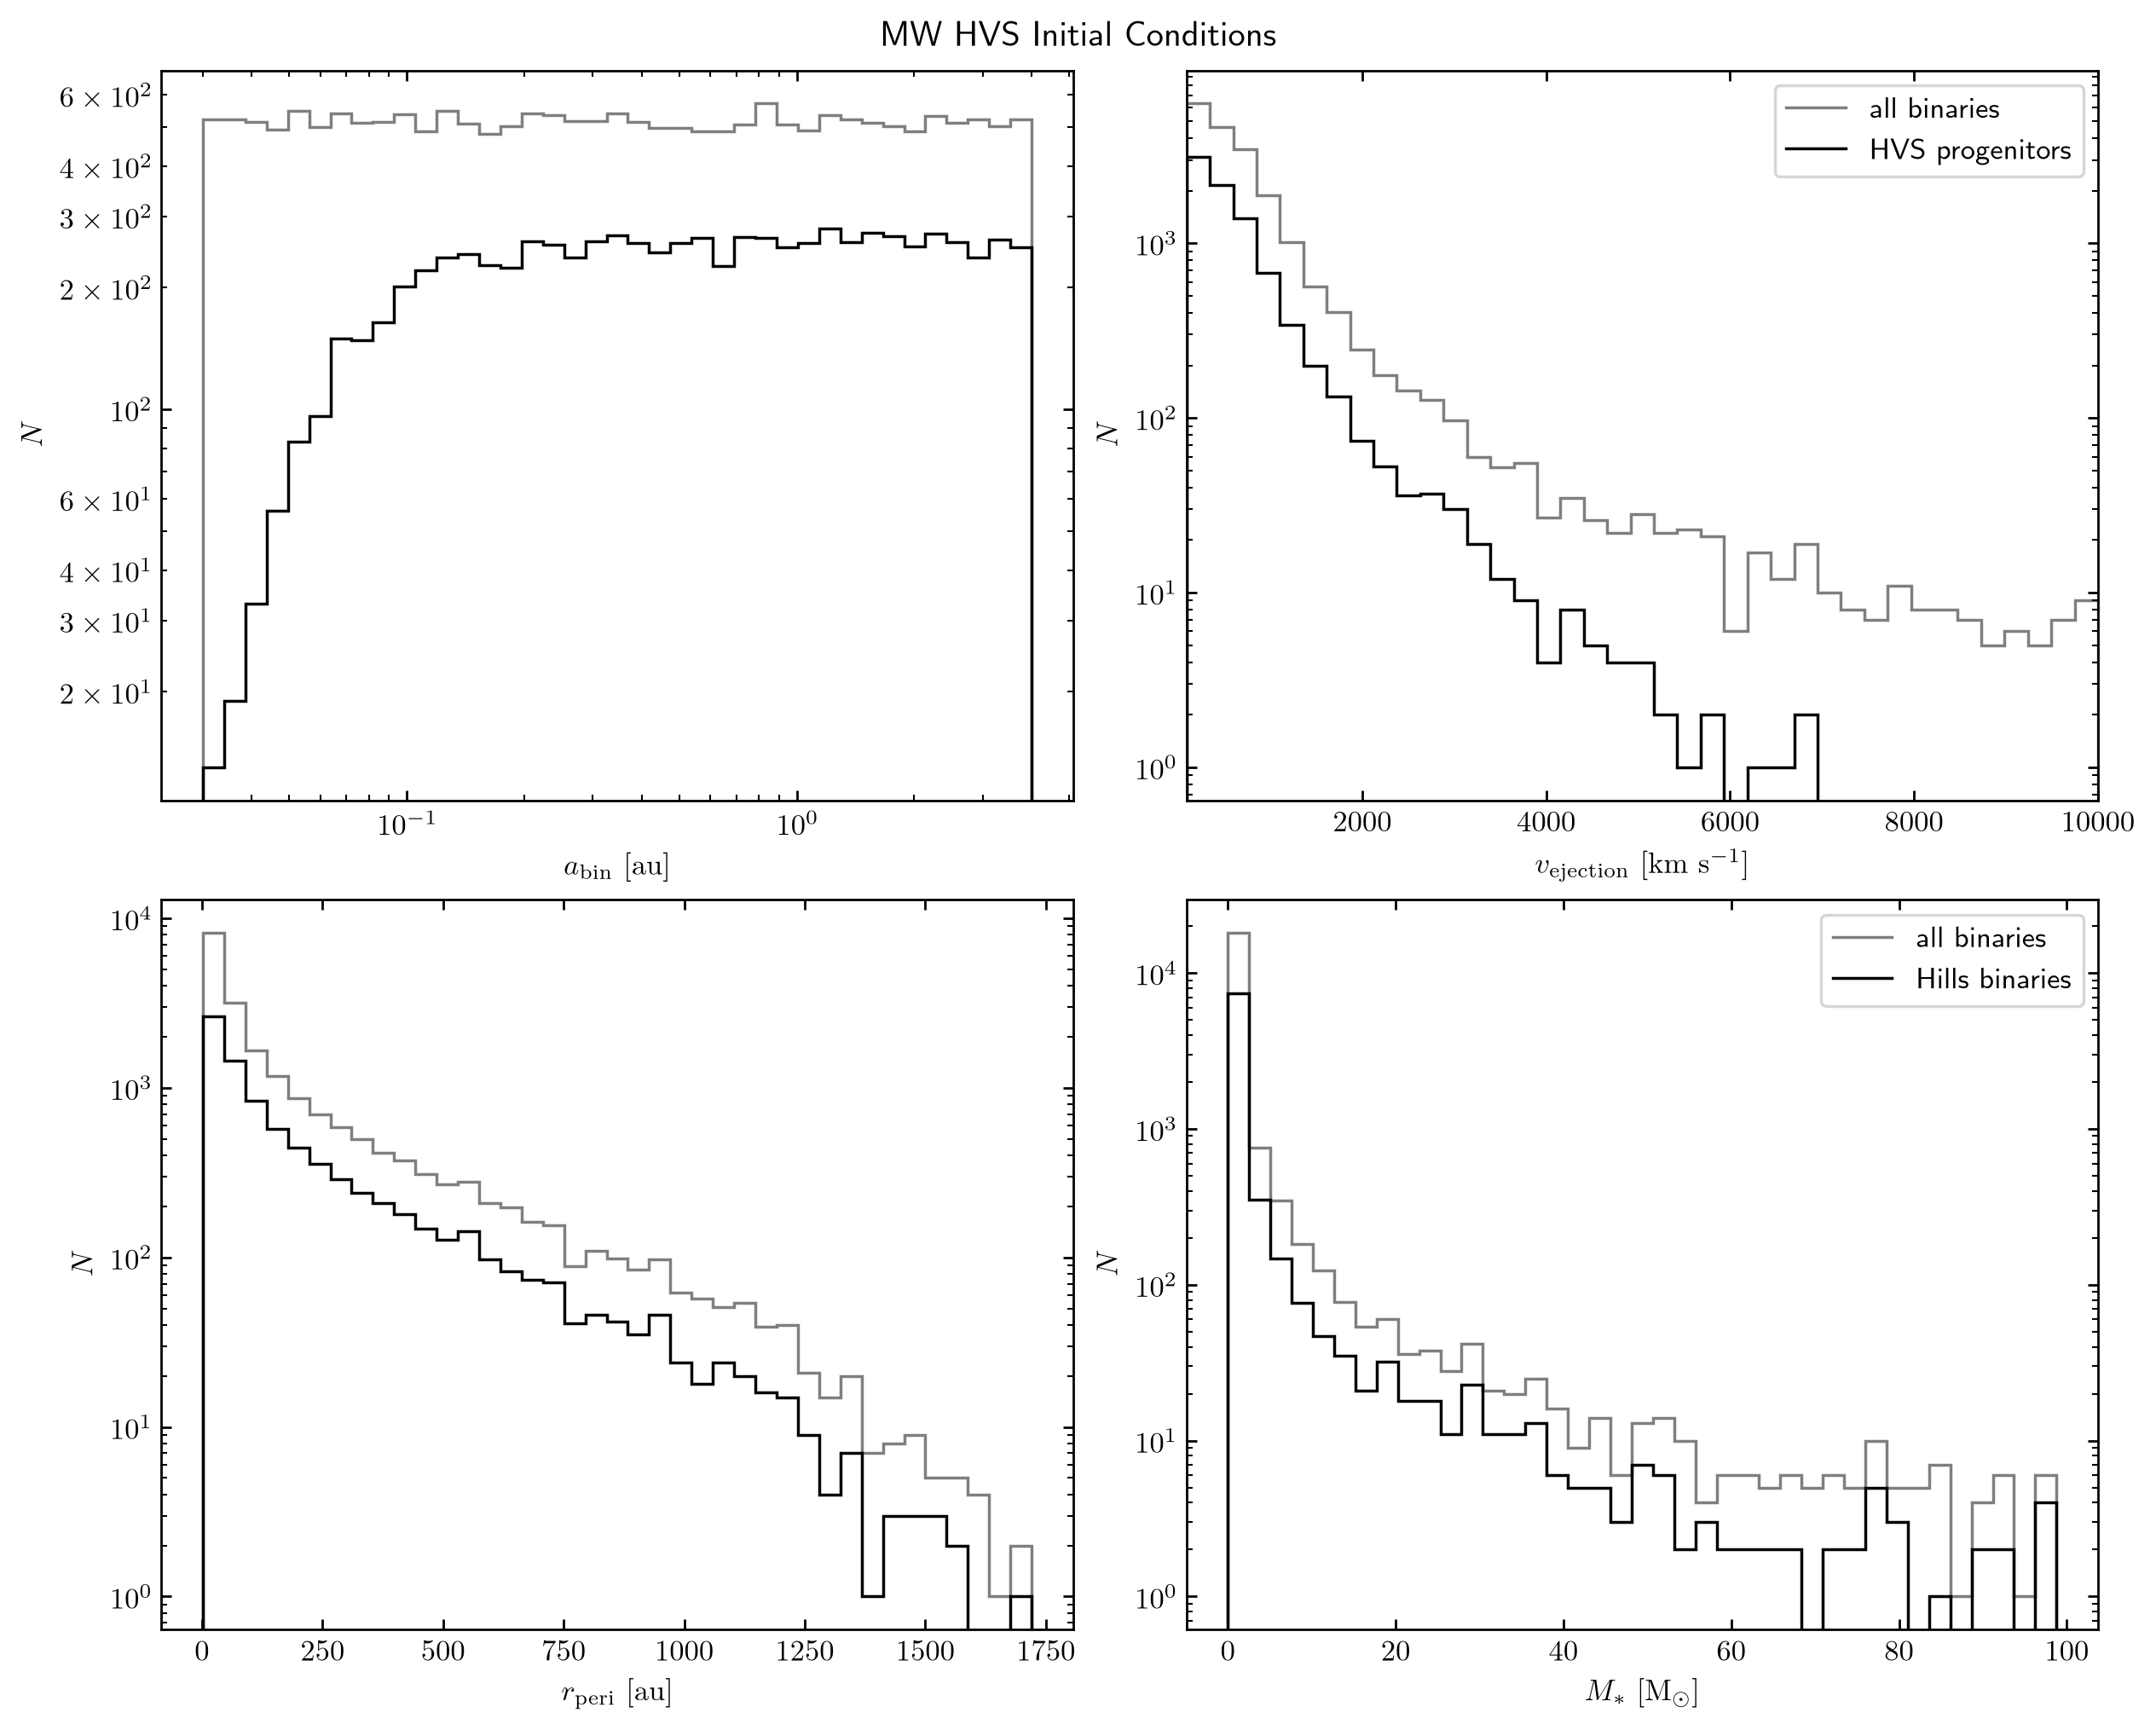

In [6]:
events, hvs_events, orbits = load_hvs_simulation_data("simulations/mw_test/r_peri_alpha2/")
plot_initial_conditions(events, title="MW HVS Initial Conditions")

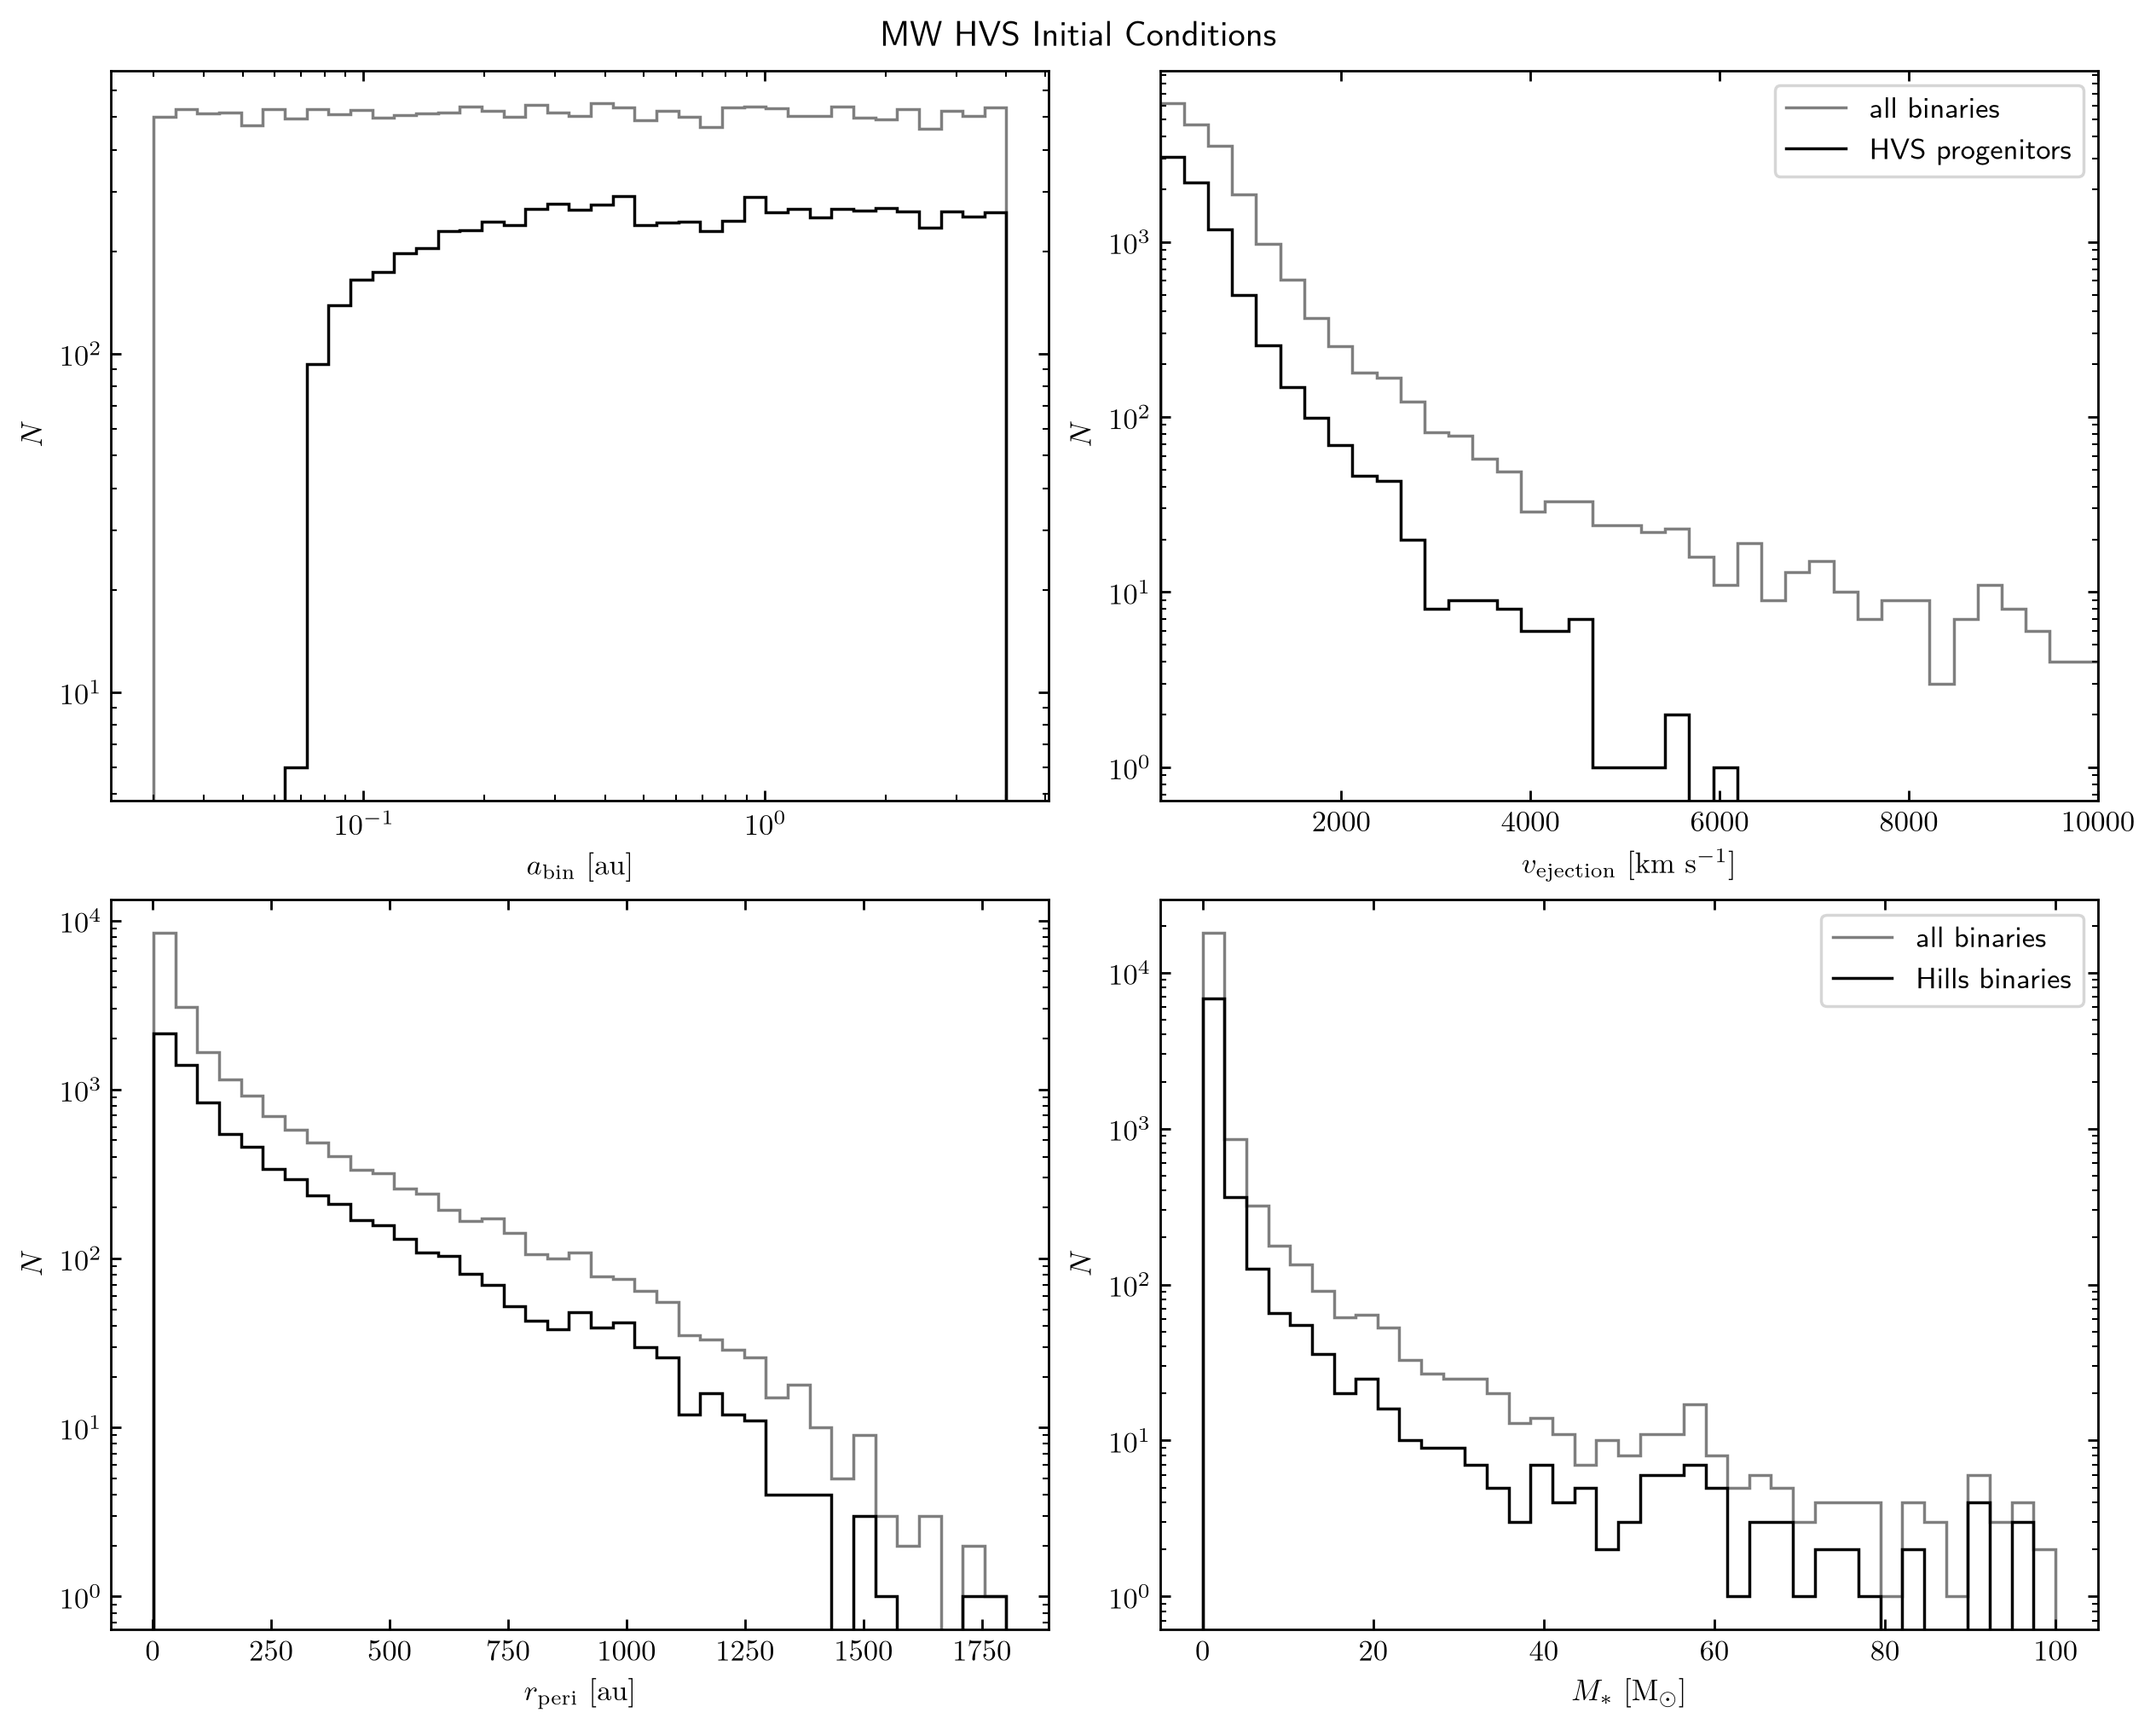

In [7]:
events, hvs_events, orbits = load_hvs_simulation_data("simulations/mw_test/r_peri_alpha2_extramask/")
plot_initial_conditions(events, title="MW HVS Initial Conditions")

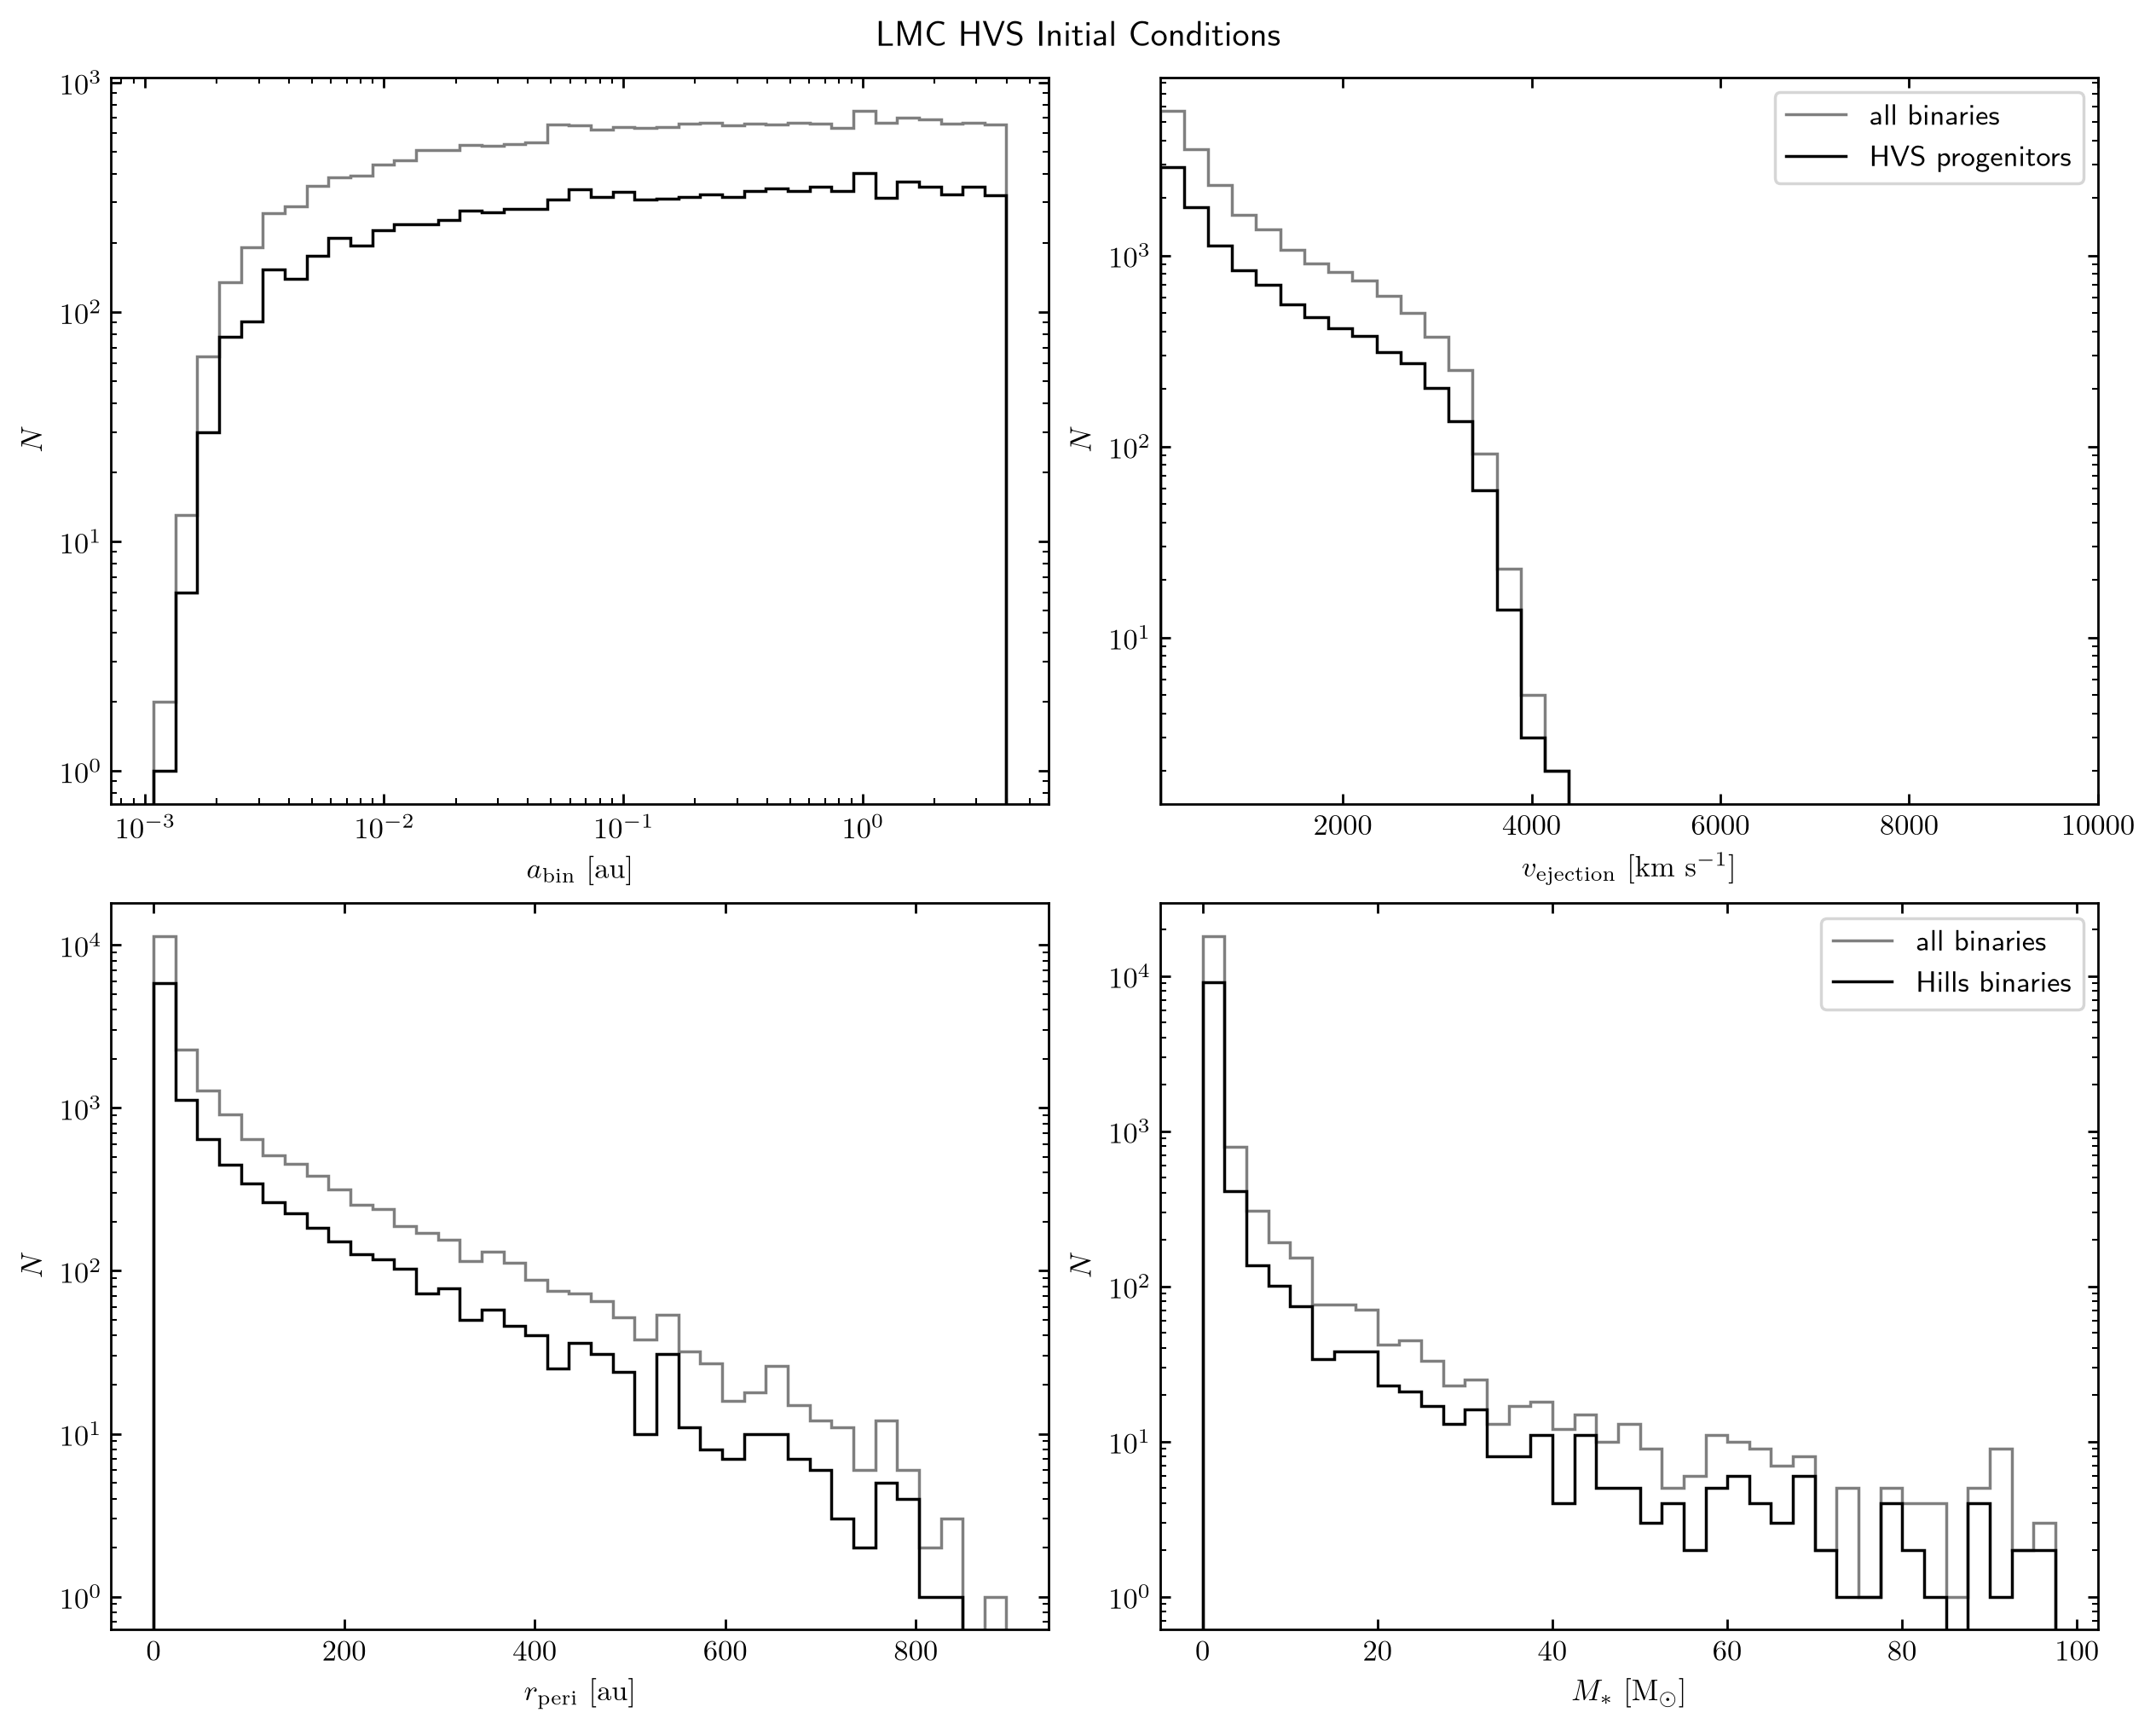

In [25]:
events, hvs_events, orbits = load_hvs_simulation_data("simulations/lmc_test/")
plot_initial_conditions(events, title="LMC HVS Initial Conditions")

In [42]:
from hvs import initialize_hvs_events

t_start = -200e6 * u.yr
t_end = 0e6 * u.yr
a_bin_min = 0.03 * u.au
a_bin_max = 4 * u.au
rate = 1e-4 * u.yr**-1
events = initialize_hvs_events(t_start=t_start, t_end=t_end, hvs_rate=rate, alpha=1.6, 
                            m_min=2.5 * u.Msun, m_max=5 * u.Msun, M_bh=6e5 * u.Msun,
                            r_peri_alpha=2)

In [43]:
from astropy.constants import G, c

R_Sch = 2 * G * 4e6 * u.Msun / c**2
print(R_Sch.to(u.au))

0.07896502971015214 AU


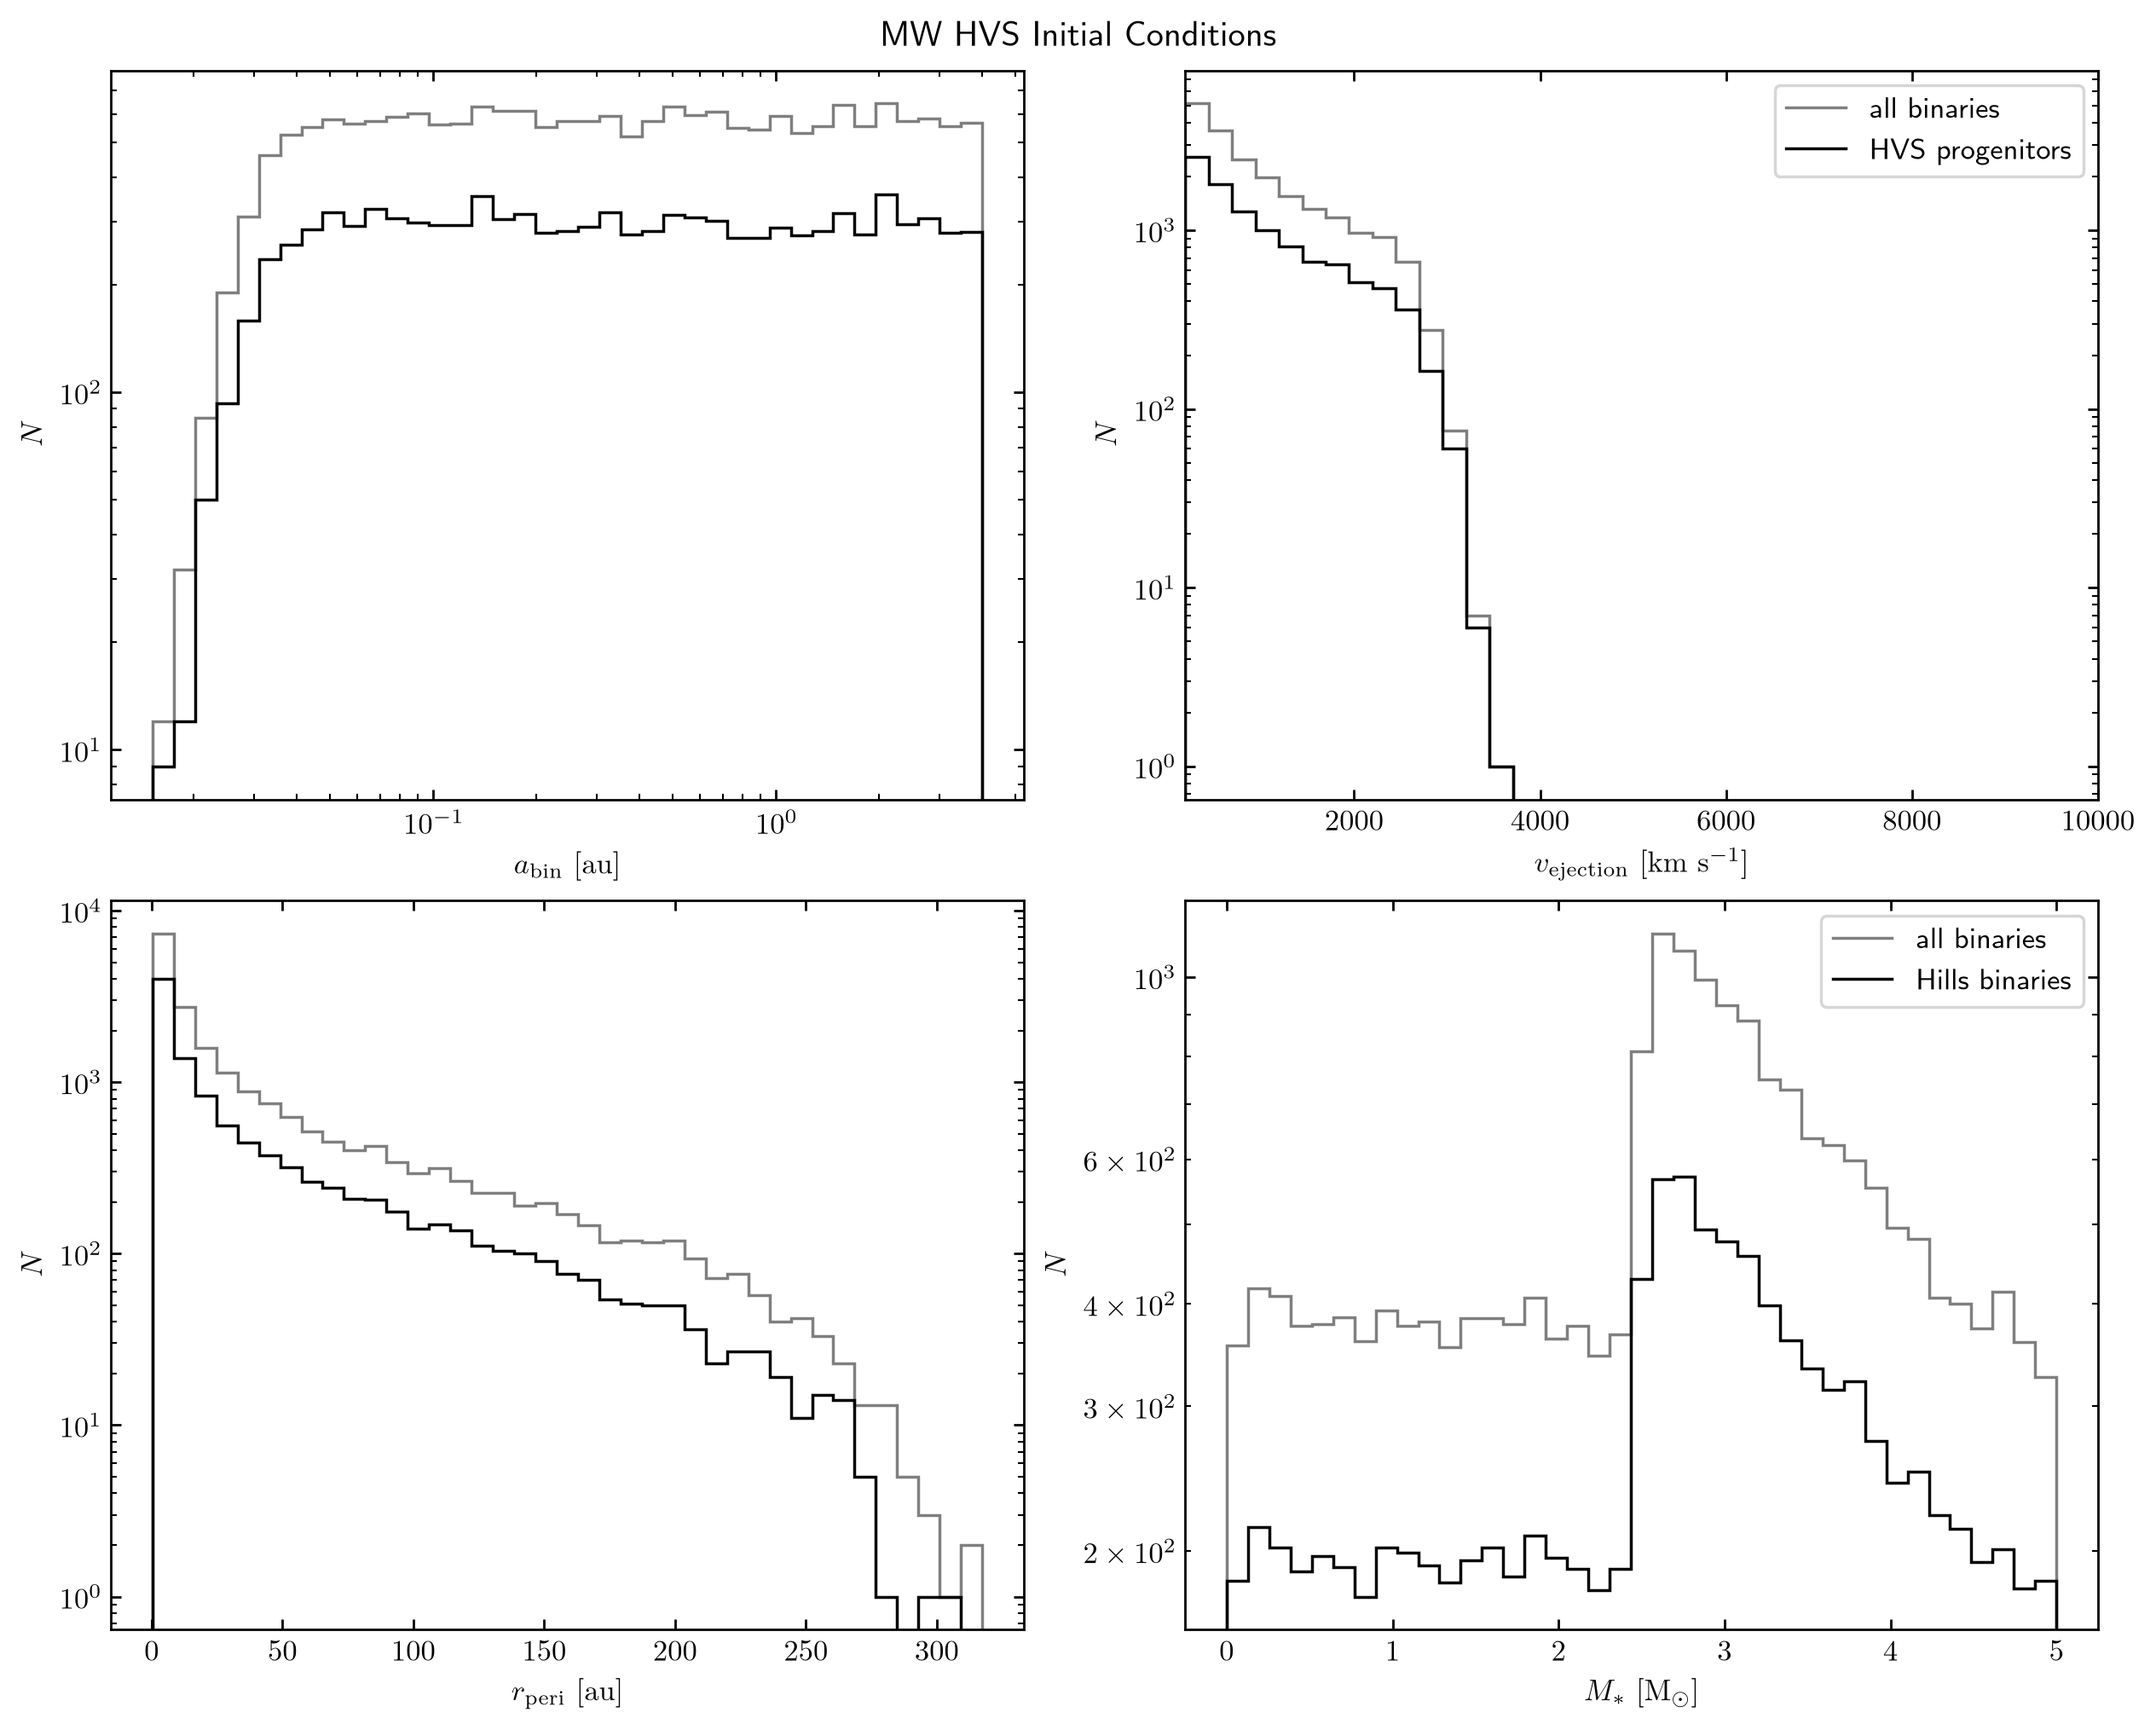

In [44]:
plot_initial_conditions(events, title="MW HVS Initial Conditions")

In [32]:
def f_R(D):
    # Polynomial fit to ejection velocity distribution from Bromley et al. (2006)
    return 0.774 + (0.0204 + (-6.23e-4 + (7.62e-6 + (-4.24e-8 + 8.62e-11 * D) * D) * D) * D) * D

def D(a_bin, r_peri, m_bin, M_bh):
    """
    Normalized distance of closest approach
    """
    return (r_peri / a_bin) * (1e6 * m_bin / (2 * M_bh))**(1 / 3)

def P_ej(D):
    return np.where(D < 175, 1 - (D / 175), 0)

def v_ej(m_bin, a_bin, r_peri, M_bh):
    return 1370 * u.km / u.s * (a_bin / (0.1 * u.au)) ** (-1/2) * (m_bin / (1 * u.Msun))**(1/3) * (M_bh / (4e6 * u.Msun))**(1/6) * f_R(D(a_bin, r_peri, m_bin, M_bh))

In [57]:
m_bin = 6 * u.Msun
a_bin = 0.1 * u.au
r_peri = 10 * u.au
M_bh = 4e6 * u.Msun
D_ = D(a_bin, r_peri, m_bin, M_bh)
v_ej_ = v_ej(m_bin, a_bin, r_peri, M_bh)
P_ej_ = P_ej(D_)
f_R_ = f_R(D_)
v_ej_, P_ej_, f_R_

(<Quantity 2101.50738317 km / s>, <Quantity 0.48082269>, <Quantity 0.84416356>)

Troubleshooting with Jesse

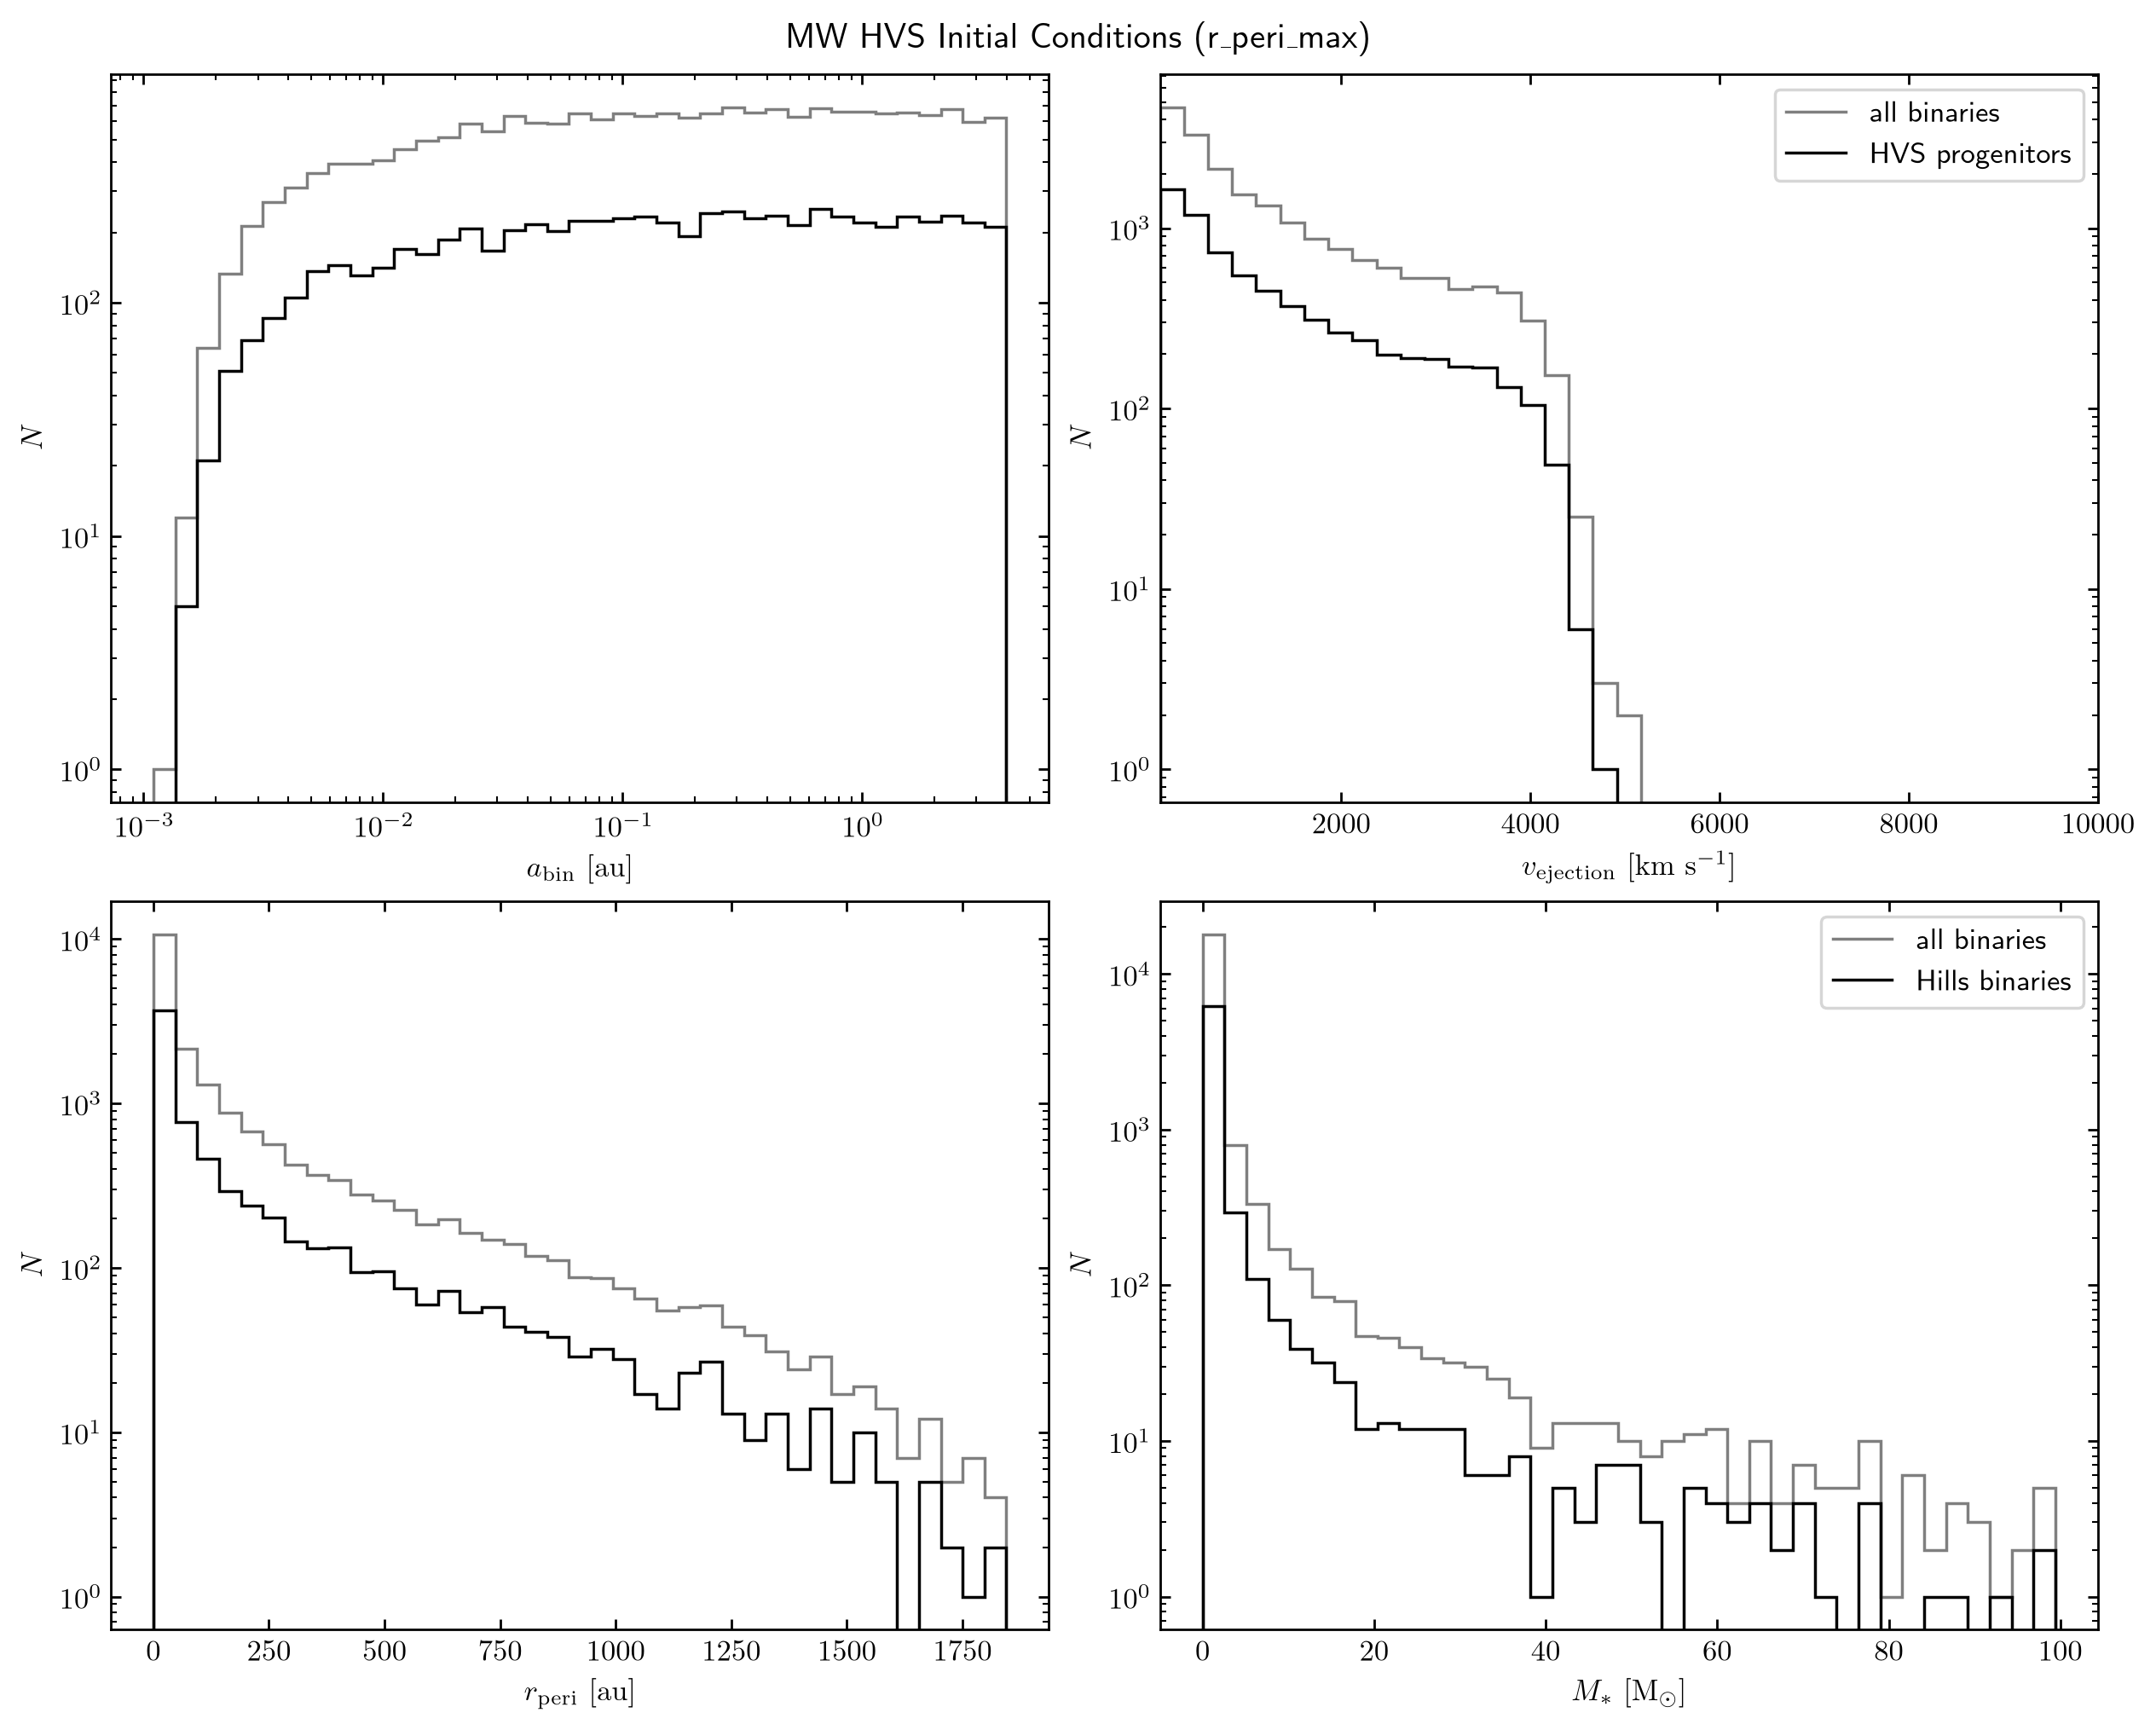

In [20]:
# load MW data
# we're trying to launch all stars either 1) at the tidal disruption radius of secondary or 2) at disruption radius of binary
dir_mw = "simulations/mw_test/r_peri_max/"
events_mw, hvs_events_mw, orbits_mw = load_hvs_simulation_data(dir_mw)
plot_initial_conditions(events_mw, title="MW HVS Initial Conditions (r_peri_max)")

In [21]:
t = 0 * u.yr
events_mw_t, orbits_mw_t = get_hvs_at_time(hvs_events_mw, orbits_mw, t)
sky_coords_mw = orbits_mw_t.SkyCoord(use_physical=True)
SDSS_u, SDSS_g, SDSS_r, SDSS_i, G_mw, BP_RP, phase = get_iso_data(events_mw_t, sky_coords_mw, t)
_, euclid_survey_cuts_mw = get_euclid_dr1_survey_cuts(sky_coords_mw, phase, G_mw, BP_RP)

detectable_mw = euclid_survey_cuts_mw['mag_cut'] & euclid_survey_cuts_mw['ms_cut'] & euclid_survey_cuts_mw['unbound_cut']
vel = events_mw_t[detectable_mw]['v_ejection'].to_value(u.km/u.s)

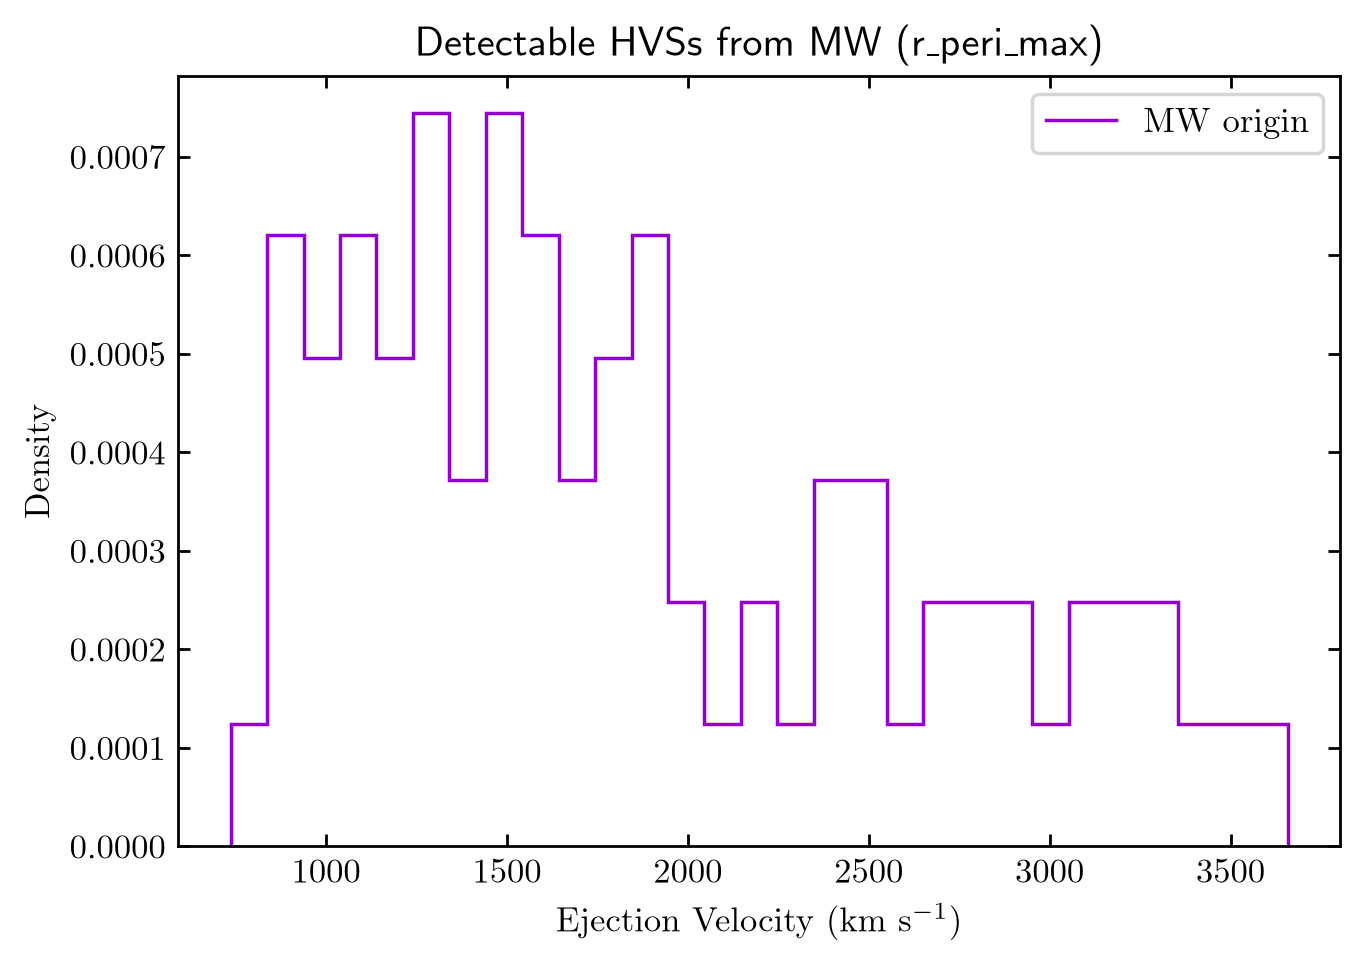

In [22]:
# histogram of ejection velocities for MW HVSs
bins = np.linspace(np.min(vel), np.max(vel), 30)
density, edges = np.histogram(vel, bins=bins, density=True)

plt.figure(figsize=(6, 4))
plt.stairs(
    density,
    edges,
    alpha=1,
    color="darkviolet",
    label=r"$\rm MW\ origin$",
)
plt.xlabel(r"$\rm Ejection\ Velocity\ (km\ s^{-1})$")
plt.ylabel(r"$\rm Density$")
plt.title(r"Detectable HVSs from MW (r_peri_max)")
plt.legend()
plt.show()

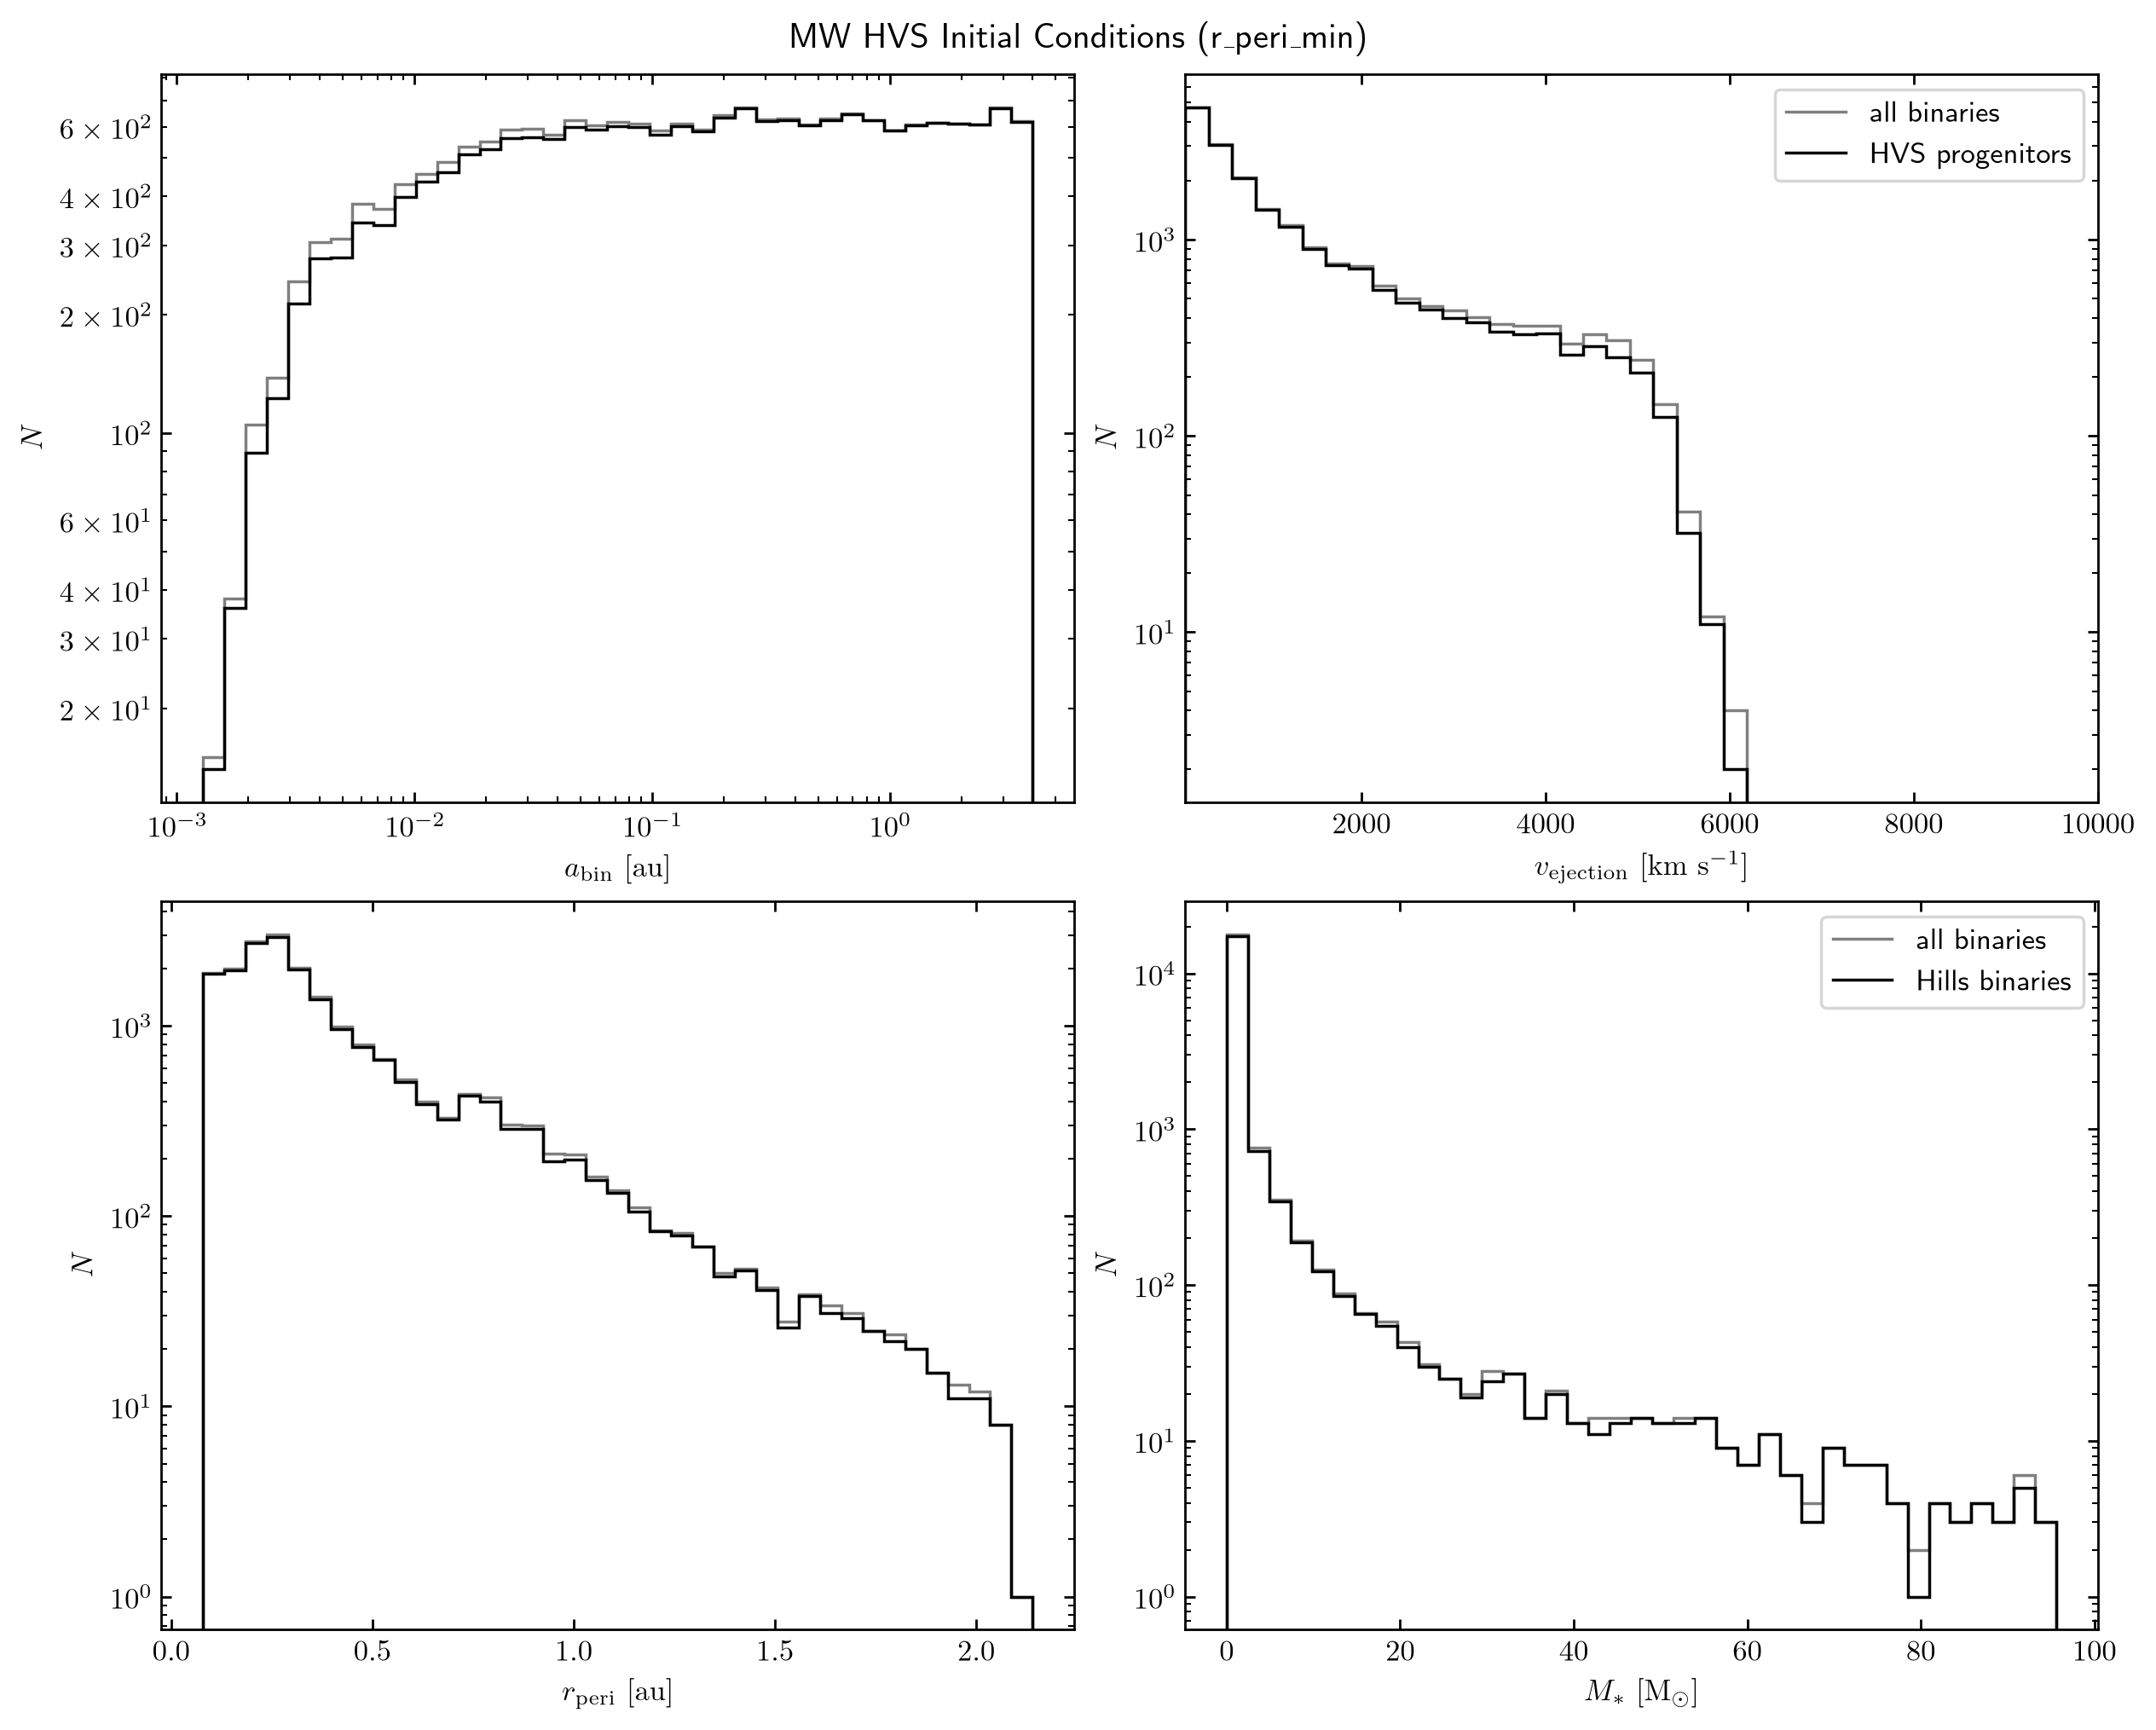

In [15]:
# load MW data
# we're trying to launch all stars either 1) at the tidal disruption radius of secondary or 2) at disruption radius of binary
dir_mw = "simulations/mw_test/r_peri_min/"
events_mw, hvs_events_mw, orbits_mw = load_hvs_simulation_data(dir_mw)
plot_initial_conditions(events_mw, title="MW HVS Initial Conditions (r_peri_min)")

In [16]:
t = 0 * u.yr
events_mw_t, orbits_mw_t = get_hvs_at_time(hvs_events_mw, orbits_mw, t)
sky_coords_mw = orbits_mw_t.SkyCoord(use_physical=True)
SDSS_u, SDSS_g, SDSS_r, SDSS_i, G_mw, BP_RP, phase = get_iso_data(events_mw_t, sky_coords_mw, t)
_, euclid_survey_cuts_mw = get_euclid_dr1_survey_cuts(sky_coords_mw, phase, G_mw, BP_RP)

detectable_mw = euclid_survey_cuts_mw['mag_cut'] & euclid_survey_cuts_mw['ms_cut'] & euclid_survey_cuts_mw['unbound_cut']
vel = events_mw_t[detectable_mw]['v_ejection'].to_value(u.km/u.s)

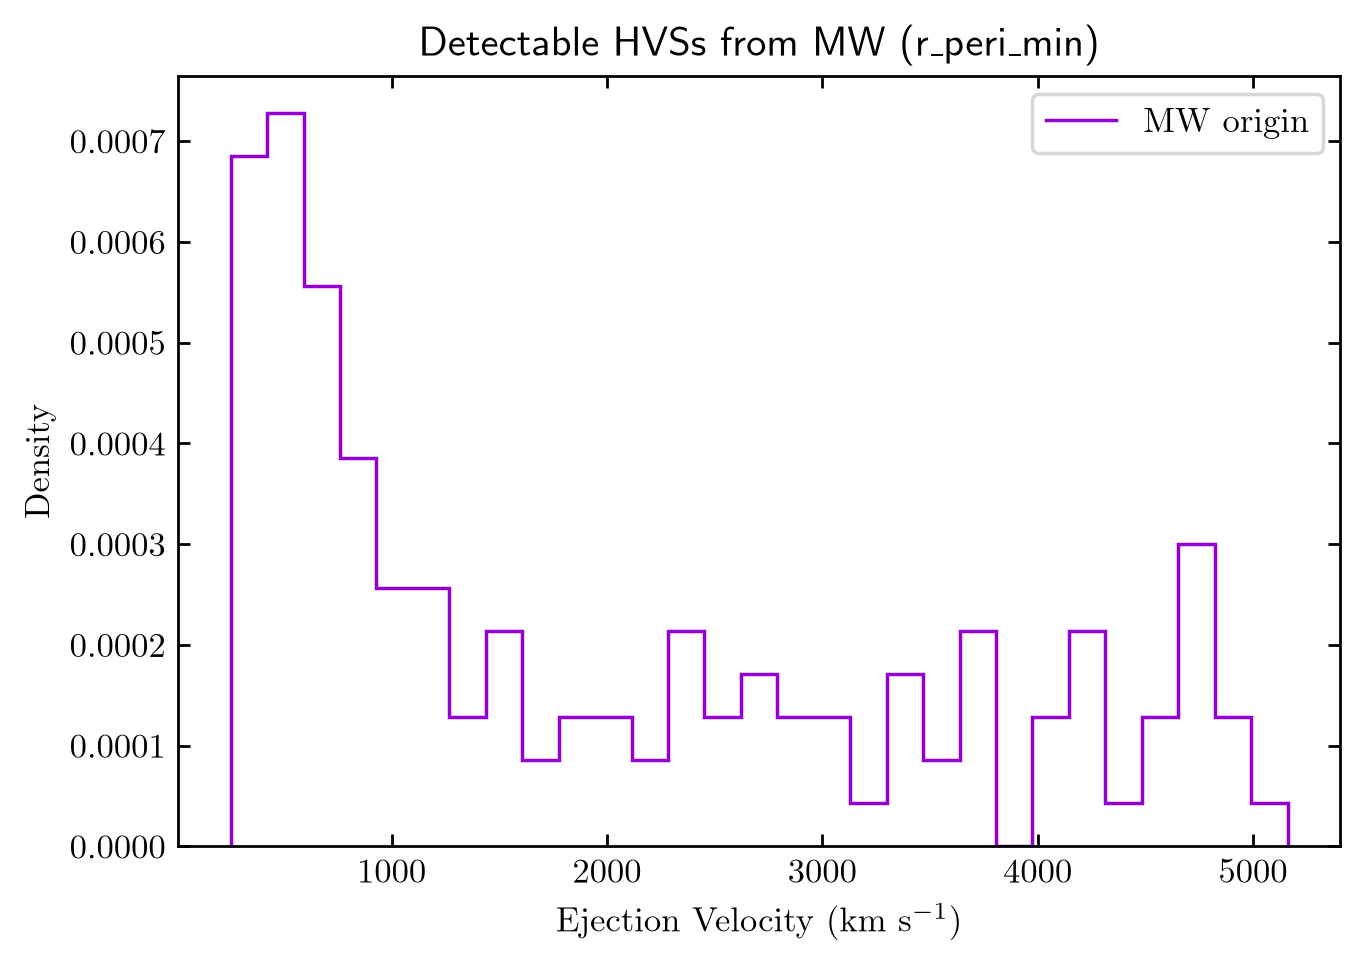

In [19]:
# histogram of ejection velocities for MW HVSs
bins = np.linspace(np.min(vel), np.max(vel), 30)
density, edges = np.histogram(vel, bins=bins, density=True)

plt.figure(figsize=(6, 4))
plt.stairs(
    density,
    edges,
    alpha=1,
    color="darkviolet",
    label=r"$\rm MW\ origin$",
)
plt.xlabel(r"$\rm Ejection\ Velocity\ (km\ s^{-1})$")
plt.ylabel(r"$\rm Density$")
plt.title(r"Detectable HVSs from MW (r_peri_min)")
plt.legend()
plt.show()